<a href="https://colab.research.google.com/github/ChristeenaGiji/Forecasting/blob/main/Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy scikit-learn matplotlib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

In [ ]:
weeks = pd.date_range(start="2023-01-01", periods=104, freq="W")

recipes = [
    "chicken_stir_fry",
    "beef_tacos",
    "vegan_salad",
    "fish_curry"
]

data = []

for recipe in recipes:

    base = np.random.randint(80,120)

    for i,w in enumerate(weeks):

        demand = base + 15*np.sin(i/6) + np.random.normal(0,5)

        data.append([w,recipe,max(int(demand),0)])

df = pd.DataFrame(data,columns=["week","recipe","orders"])

df.head()

,week,recipe,orders
0,2023-01-01,chicken_stir_fry,114
1,2023-01-08,chicken_stir_fry,124
2,2023-01-15,chicken_stir_fry,124
3,2023-01-22,chicken_stir_fry,115
4,2023-01-29,chicken_stir_fry,136


In [ ]:
df["lag_1"] = df.groupby("recipe")["orders"].shift(1)
df["lag_2"] = df.groupby("recipe")["orders"].shift(2)
df["lag_4"] = df.groupby("recipe")["orders"].shift(4)

In [ ]:
df["rolling_mean_4"] = df.groupby("recipe")["orders"].rolling(4).mean().reset_index(0,drop=True)

In [ ]:
df['rolling_std_4'] = df.groupby('recipe')['orders'].rolling(4).std().reset_index(0,drop=True)

In [ ]:
df["week_number"] = df["week"].dt.isocalendar().week.astype(int)

df["month"] = df["week"].dt.month

df["year"] = df["week"].dt.year

In [ ]:
holiday_dates = pd.to_datetime(['2023-12-25','2024-01-01'])
df['holiday_flag'] = df['week'].isin(holiday_dates).astype(int)

In [ ]:
df = df.dropna()

In [ ]:
df = pd.get_dummies(df,columns=["recipe"])

In [ ]:
df

,week,orders,lag_1,lag_2,lag_4,rolling_mean_4,rolling_std_4,week_number,month,year,holiday_flag,recipe_beef_tacos,recipe_chicken_stir_fry,recipe_fish_curry,recipe_vegan_salad
4,2023-01-29,136,115.0,124.0,114.0,124.75,8.616844,4,1,2023,0,False,True,False,False
5,2023-02-05,128,136.0,115.0,124.0,125.75,8.732125,5,2,2023,0,False,True,False,False
6,2023-02-12,121,128.0,136.0,124.0,125.00,9.055385,6,2,2023,0,False,True,False,False
7,2023-02-19,130,121.0,128.0,115.0,128.75,6.184658,7,2,2023,0,False,True,False,False
8,2023-02-26,132,130.0,121.0,136.0,127.75,4.787136,8,2,2023,0,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
411,2024-11-24,100,110.0,107.0,119.0,108.00,6.271629,47,11,2024,0,False,False,True,False
412,2024-12-01,111,100.0,110.0,115.0,107.00,4.966555,48,12,2024,0,False,False,True,False
413,2024-12-08,112,111.0,100.0,107.0,108.25,5.560276,49,12,2024,0,False,False,True,False
414,2024-12-15,106,112.0,111.0,110.0,107.25,5.500000,50,12,2024,0,False,False,True,False


In [ ]:
features = ['lag_1','lag_2','lag_4','rolling_mean_4','rolling_std_4',
            'holiday_flag','month','week_number','year'] + [c for c in df.columns if "recipe_" in c]
X = df[features]
y = df['orders']

In [ ]:
X

,lag_1,lag_2,lag_4,rolling_mean_4,week_number,month,year,recipe_beef_tacos,recipe_chicken_stir_fry,recipe_fish_curry,recipe_vegan_salad
4,101.0,100.0,92.0,103.50,4,1,2023,False,True,False,False
5,105.0,101.0,108.0,105.00,5,2,2023,False,True,False,False
6,114.0,105.0,100.0,107.75,6,2,2023,False,True,False,False
7,111.0,114.0,101.0,109.50,7,2,2023,False,True,False,False
8,108.0,111.0,105.0,112.00,8,2,2023,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...
411,79.0,89.0,97.0,88.25,47,11,2024,False,False,True,False
412,93.0,79.0,92.0,85.25,48,12,2024,False,False,True,False
413,80.0,93.0,89.0,83.50,49,12,2024,False,False,True,False
414,82.0,80.0,79.0,82.75,50,12,2024,False,False,True,False


In [ ]:
import lightgbm as lgb
train_data = lgb.Dataset(X, label=y)

params = {
    'objective': 'regression',
    'metric': 'mae',
    'learning_rate': 0.1,
    'num_leaves': 31,
    'random_state': 42
}

lgb_model = lgb.train(params, train_data, num_boost_round=200)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000329 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 507
[LightGBM] [Info] Number of data points in the train set: 400, number of used features: 12
[LightGBM] [Info] Start training from score 103.820000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [ ]:
future_rows = []

for recipe in recipes:
    last = df[df.filter(like=recipe).any(axis=1)].iloc[-1:]

    for i in range(4):
        X_future = last[features]
        pred = lgb_model.predict(X_future)[0]

        new_row = last.copy()
        new_row['lag_1'] = pred
        new_row['lag_2'] = last['lag_1'].values[0]
        new_row['lag_4'] = last['lag_2'].values[0]
        new_row['rolling_mean_4'] = (new_row['lag_1'] + new_row['lag_2'] + last['lag_2'].values[0] + last['lag_4'].values[0])/4
        new_row['rolling_std_4'] = last['rolling_std_4'].values[0]
        new_row['week'] = last['week'] + pd.Timedelta(weeks=1)
        new_row['week_number'] = new_row['week'].dt.isocalendar().week.astype(int)
        new_row['month'] = new_row['week'].dt.month
        new_row['year'] = new_row['week'].dt.year

        future_rows.append({"week":new_row['week'].values[0], "recipe":recipe, "forecast_orders":pred})
        last = new_row

forecast_df = pd.DataFrame(future_rows)

In [ ]:
recipe_ingredients = pd.DataFrame({
    "recipe":["chicken_stir_fry","chicken_stir_fry","beef_tacos","vegan_salad","fish_curry"],
    "ingredient":["chicken","soy_sauce","beef","lettuce","fish"],
    "qty":[0.2,0.05,0.25,0.15,0.3]
})

In [ ]:
ingredient_calendar = pd.DataFrame({
    "ingredient":["fish","fish"],
    "month":[6,7]  # fish unavailable June and July
})

In [ ]:
ingredient_forecast = forecast_df.merge(recipe_ingredients, on="recipe")
ingredient_forecast["ingredient_demand"] = ingredient_forecast["forecast_orders"] * ingredient_forecast["qty"]

In [ ]:
# 1️⃣ Add month to forecast_df
forecast_df['month'] = pd.to_datetime(forecast_df['week']).dt.month

# 2️⃣ Merge with recipe_ingredients
ingredient_forecast = forecast_df.merge(recipe_ingredients, on="recipe")

# 3️⃣ Calculate ingredient demand
ingredient_forecast["ingredient_demand"] = ingredient_forecast["forecast_orders"] * ingredient_forecast["qty"]

# 4️⃣ Remove ingredients unavailable in that month
ingredient_forecast = ingredient_forecast.merge(
    ingredient_calendar,
    on=["ingredient","month"],
    how="left",
    indicator=True
)

ingredient_forecast = ingredient_forecast[ingredient_forecast["_merge"]=="left_only"]
ingredient_forecast = ingredient_forecast.drop(columns="_merge")

# 5️⃣ Aggregate supplier orders
supplier_orders = ingredient_forecast.groupby("ingredient")["ingredient_demand"].sum().reset_index()
supplier_orders

,ingredient,ingredient_demand
0,beef,74.563412
1,chicken,77.588664
2,fish,129.439842
3,lettuce,47.199042
4,soy_sauce,19.397166


In [ ]:
supplier_orders = ingredient_forecast.groupby("ingredient")["ingredient_demand"].sum().reset_index()
supplier_orders

,ingredient,ingredient_demand
0,beef,74.563412
1,chicken,77.588664
2,fish,129.439842
3,lettuce,47.199042
4,soy_sauce,19.397166


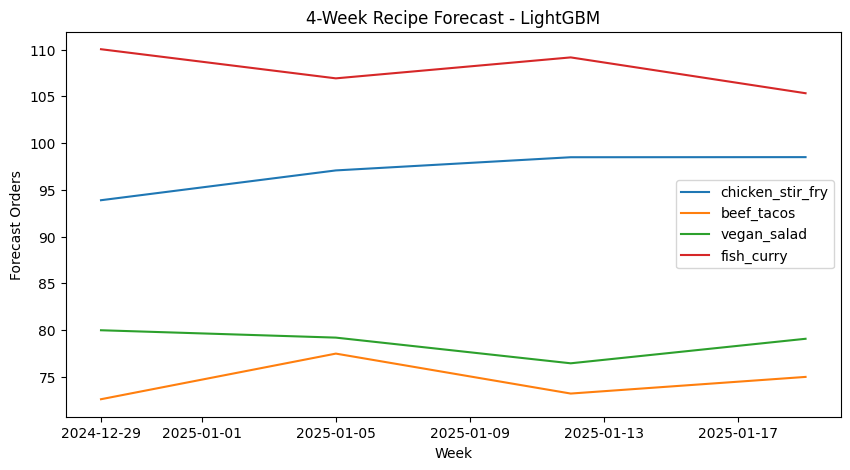

In [ ]:
plt.figure(figsize=(10,5))
for recipe in recipes:
    temp = forecast_df[forecast_df["recipe"]==recipe]
    plt.plot(temp["week"], temp["forecast_orders"], label=recipe)
plt.title("4-Week Recipe Forecast - LightGBM")
plt.xlabel("Week")
plt.ylabel("Forecast Orders")
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb

# ------------------------------
# 1️⃣ Historical data with orders
historical_data = pd.DataFrame({
    'recipe_id': [1, 2, 3, 4, 5],
    'date': pd.to_datetime(['2026-03-01', '2026-03-02', '2026-03-03', '2026-03-04', '2026-03-05']),
    'ingredient_count': [5, 7, 6, 8, 5],
    'prep_time': [30, 45, 35, 50, 25],
    'category': ['dessert', 'dessert', 'main', 'dessert', 'main'],
    'orders': [120, 200, 150, 250, 130]  # target column
})

# 2️⃣ Create lag/rolling features for orders
historical_data = historical_data.sort_values('date')
historical_data['lag_1'] = historical_data['orders'].shift(1).fillna(historical_data['orders'].mean())
historical_data['lag_2'] = historical_data['orders'].shift(2).fillna(historical_data['orders'].mean())
historical_data['lag_3'] = historical_data['orders'].shift(3).fillna(historical_data['orders'].mean())
historical_data['rolling_mean'] = historical_data['orders'].rolling(3, min_periods=1).mean()
historical_data['rolling_std'] = historical_data['orders'].rolling(3, min_periods=1).std().fillna(0)

historical_data

,recipe_id,date,ingredient_count,prep_time,category,orders,lag_1,lag_2,lag_3,rolling_mean,rolling_std
0,1,2026-03-01,5,30,dessert,120,170.0,170.0,170.0,120.000000,0.000000
1,2,2026-03-02,7,45,dessert,200,120.0,170.0,170.0,160.000000,56.568542
2,3,2026-03-03,6,35,main,150,200.0,120.0,170.0,156.666667,40.414519
3,4,2026-03-04,8,50,dessert,250,150.0,200.0,120.0,200.000000,50.000000
4,5,2026-03-05,5,25,main,130,250.0,150.0,200.0,176.666667,64.291005


In [ ]:
# 3️⃣ Train LightGBM model
features = ['ingredient_count', 'prep_time', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean', 'rolling_std']
target = 'orders'

train_data = lgb.Dataset(historical_data[features], label=historical_data[target])

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.1,
    'num_leaves': 31,
    'verbose': -1
}

model = lgb.train(params, train_data, num_boost_round=50)

# 4️⃣ Update function to work with orders
def predict_new_recipe(model, new_recipe, historical_data, target_col='orders',
                       lag_cols=['lag_1','lag_2','lag_3'], rolling_cols=['rolling_mean','rolling_std'],
                       category_col='category'):

    if category_col in new_recipe.columns:
        cat = new_recipe[category_col].iloc[0]
        similar = historical_data[historical_data[category_col] == cat]
    else:
        similar = historical_data

    # lag features fallback
    lag_values = []
    for lag in lag_cols:
        if len(similar) >= int(lag.split('_')[1]):
            lag_val = similar[target_col].iloc[-int(lag.split('_')[1])]
        else:
            lag_val = similar[target_col].mean()
        lag_values.append(lag_val)

    # rolling features fallback
    rolling_values = []
    for rc in rolling_cols:
        if rc == 'rolling_mean':
            rolling_values.append(similar[target_col].mean())
        elif rc == 'rolling_std':
            rolling_values.append(similar[target_col].std() if len(similar) > 1 else 0)
        else:
            rolling_values.append(0)

    feature_dict = {col: val for col, val in zip(lag_cols + rolling_cols, lag_values + rolling_values)}

    # add static features
    static_features = [c for c in new_recipe.columns if c not in [category_col]]
    for sf in static_features:
        feature_dict[sf] = new_recipe[sf].iloc[0]

    feature_df = pd.DataFrame([feature_dict])
    prediction = model.predict(feature_df)
    return prediction[0]

# 5️⃣ Predict for a new recipe
new_recipe = pd.DataFrame({
    'ingredient_count': [6],
    'prep_time': [40],
    'category': ['dessert']
})

predicted_orders = predict_new_recipe(model, new_recipe, historical_data, target_col='orders')
print(f"Predicted orders for new recipe: {predicted_orders:.2f}")

Predicted orders for new recipe: 170.00


In [ ]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X,y)

RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
recipe_ingredients = pd.DataFrame({

"recipe":[
"chicken_stir_fry","chicken_stir_fry",
"beef_tacos",
"vegan_salad",
"fish_curry"
],

"ingredient":[
"chicken","soy_sauce",
"beef",
"lettuce",
"fish"
],

"qty":[
0.2,
0.05,
0.25,
0.15,
0.3
]

})

In [ ]:
ingredient_calendar = pd.DataFrame({

"ingredient":["fish","fish","soy_sauce"],

"month":[6,7,8]

})

In [ ]:
future_rows = []

for recipe in recipes:

    last = df[df.filter(like=recipe).any(axis=1)].iloc[-1:]

    for i in range(4):

        X_future = last[features]

        pred = model.predict(X_future)[0]

        new_row = last.copy()

        new_row["lag_1"] = pred
        new_row["lag_2"] = last["lag_1"].values[0]
        new_row["lag_4"] = last["lag_2"].values[0]

        new_row["rolling_mean_4"] = (
            new_row["lag_1"] +
            new_row["lag_2"] +
            last["lag_2"].values[0] +
            last["lag_4"].values[0]
        ) / 4

        new_row["week"] = last["week"] + pd.Timedelta(weeks=1)

        new_row["week_number"] = new_row["week"].dt.isocalendar().week.astype(int)
        new_row["month"] = new_row["week"].dt.month
        new_row["year"] = new_row["week"].dt.year

        future_rows.append({
            "week":new_row["week"].values[0],
            "recipe":recipe,
            "forecast_orders":pred
        })

        last = new_row

In [ ]:
forecast_df = pd.DataFrame(future_rows)

forecast_df.head()

,week,recipe,forecast_orders
0,2024-12-29,chicken_stir_fry,86.420
1,2025-01-05,chicken_stir_fry,84.200
2,2025-01-12,chicken_stir_fry,84.005
3,2025-01-19,chicken_stir_fry,84.510
4,2024-12-29,beef_tacos,76.960


In [ ]:
ingredient_forecast = forecast_df.merge(
    recipe_ingredients,
    on="recipe"
)

ingredient_forecast["ingredient_demand"] = (
    ingredient_forecast["forecast_orders"]
    * ingredient_forecast["qty"]
)

In [ ]:
ingredient_forecast = ingredient_forecast.merge(
    ingredient_calendar,
    on=["ingredient","month"],
    how="left",
    indicator=True
)

ingredient_forecast = ingredient_forecast[
    ingredient_forecast["_merge"]=="left_only"
]

KeyError: 'month'